In [ ]:
!pip install ultralytics -q
!pip install pyyaml pandas seaborn -q


import os
import yaml
import shutil
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import drive
from sklearn.model_selection import train_test_split

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Thesis_Z"

# Dataset paths
DATASETS = {
    "cloudy": f"{BASE}/cloudy",
    "rainy": f"{BASE}/rainy",
    "snowy": f"{BASE}/snowy"
}

# Working directories
WORK_DIR = "/content/weather_pipeline"
MERGED = f"{WORK_DIR}/merged"
FINAL_DATASET = f"{WORK_DIR}/final_dataset"

os.makedirs(WORK_DIR, exist_ok=True)

upload final dataset[merged-split-new YML]

In [ ]:
FINAL_DATASET = "/content/drive/MyDrive/Thesis_Z/final_dataset"
yaml_path = FINAL_DATASET + "/data.yaml"

print("Using cached dataset:", FINAL_DATASET)

Using cached dataset: /content/drive/MyDrive/Thesis_Z/final_dataset


In [ ]:

# Load the data.yaml file
with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

# Update the 'path' to point to the correct Google Drive location
data_config["path"] = FINAL_DATASET

# Save the updated data.yaml file back
with open(yaml_path, "w") as f:
    yaml.dump(data_config, f)

print(f"Updated data.yaml path to: {FINAL_DATASET}")

Updated data.yaml path to: /content/drive/MyDrive/Thesis_Z/final_dataset


In [ ]:
import shutil

DRIVE_DATASET = "/content/drive/MyDrive/Thesis_Z/final_dataset"
LOCAL_DATASET = "/content/final_dataset"

if not os.path.exists(LOCAL_DATASET):
    print("Copying dataset to local disk...")
    shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)

yaml_path = LOCAL_DATASET + "/data.yaml"

print("Dataset ready at:", LOCAL_DATASET)

Copying dataset to local disk...
Dataset ready at: /content/final_dataset


train

In [ ]:
model = YOLO("yolov8m.pt")

model.train(
    data=yaml_path,
    epochs=50,
    imgsz=512,
    batch=12,
    optimizer="AdamW",
    cache="disk",
    workers=4,
    seed=42,
    pretrained=True,
    project=WORK_DIR,
    name="weather_detection",
    plots=True,
    save_period=5,      # save checkpoint every 5 epochs
    device=0
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weather_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ae9acf259d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

save train [run it instead of training  each time]

In [ ]:
import shutil

DRIVE_MODEL = "/content/drive/MyDrive/Thesis_Z/best_model.pt"

shutil.copy(
    f"{WORK_DIR}/weather_detection/weights/best.pt",
    DRIVE_MODEL
)

print("Model saved to Drive:", DRIVE_MODEL)

Model saved to Drive: /content/drive/MyDrive/Thesis_Z/best_model.pt


In [ ]:
save all

In [ ]:
import shutil

SOURCE = f"{WORK_DIR}/weather_detection"
DEST = "/content/drive/MyDrive/Thesis_Z/weather_detection"

shutil.copytree(SOURCE, DEST, dirs_exist_ok=True)

print("Training folder saved to Drive.")

Training folder saved to Drive.


load all saved

In [ ]:
from ultralytics import YOLO

best = YOLO("/content/drive/MyDrive/Thesis_Z/weather_detection/weights/best.pt")

print("Best model loaded")

Best model loaded


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/drive/MyDrive/Thesis_Z/weather_detection/results.csv")

print(results.head())

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   284.877         2.16667         2.20118         1.79650   
1      2   563.488         2.07256         1.99799         1.74846   
2      3   840.893         1.96639         1.82257         1.67106   
3      4  1116.920         1.90256         1.72480         1.62177   
4      5  1392.890         1.84745         1.61255         1.58025   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.44027            0.07157           0.05015   
1               0.51098            0.17820           0.16593   
2               0.32261            0.22332           0.16255   
3               0.48300            0.24985           0.24293   
4               0.58196            0.29650           0.31407   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.01942       2.36352       2.65340       2.07921  0.003329   
1              0.07533       2.06421  

load best model

In [ ]:
from ultralytics import YOLO

best = YOLO(f"{WORK_DIR}/weather_detection/weights/best.pt")
#best = YOLO("/content/drive/MyDrive/Thesis_Z/best_model.pt")

print("Best model loaded")

Best model loaded


In [ ]:
from ultralytics import YOLO

#best = YOLO(f"{WORK_DIR}/weather_detection/weights/best.pt")
best = YOLO("/content/drive/MyDrive/Thesis_Z/best_model.pt")

print("Best model loaded")

Best model loaded


validation metrix

In [ ]:
val_metrics = best.val(data=yaml_path, split="val")

print("Validation Results")
print("mAP50:", val_metrics.box.map50)
print("mAP50-95:", val_metrics.box.map)
print("Precision:", val_metrics.box.mp)
print("Recall:", val_metrics.box.mr)

# F1 score
precision = val_metrics.box.mp
recall = val_metrics.box.mr
f1 = 2*(precision*recall)/(precision+recall)

print("F1 Score:", f1)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,851,340 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 6.1±3.4 MB/s, size: 37.2 KB)
val: Scanning /content/drive/MyDrive/Thesis_Z/final_dataset/val/labels.cache... 2694 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2694/2694 538.1Mit/s 0.0s
val: /content/drive/MyDrive/Thesis_Z/final_dataset/val/images/5494.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/Thesis_Z/final_dataset/val/images/5501.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/Thesis_Z/final_dataset/val/images/5506.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/Thesis_Z/final_dataset/val/images/5535.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/Thesis_Z/final_dataset/val/images/5554.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/Thesis_Z/final_dataset/val/images/5561.jpg: 1 duplicate labels removed

test metrix

In [ ]:
test_metrics = best.val(data=yaml_path, split="test")

print("Test Results")
print("mAP50:", test_metrics.box.map50)
print("mAP50-95:", test_metrics.box.map)
print("Precision:", test_metrics.box.mp)
print("Recall:", test_metrics.box.mr)

precision = test_metrics.box.mp
recall = test_metrics.box.mr
f1 = 2*(precision*recall)/(precision+recall)

print("F1 Score:", f1)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 6.3±2.8 MB/s, size: 32.2 KB)
val: Scanning /content/drive/MyDrive/Thesis_Z/final_dataset/test/labels.cache... 1327 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1327/1327 278.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 973, len(boxes) = 15346. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 83/83 2.3it/s 35.8s
                   all       1327      15346      0.735      0.634      0.679      0.429
                  bike         56         79      0.794      0.646      0.685       0.35
                   bus        150        193      0.807      0.845      0.877      0.638
     

training log

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv(f"{WORK_DIR}/weather_detection/results.csv")

print(results.head())

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   284.877         2.16667         2.20118         1.79650   
1      2   563.488         2.07256         1.99799         1.74846   
2      3   840.893         1.96639         1.82257         1.67106   
3      4  1116.920         1.90256         1.72480         1.62177   
4      5  1392.890         1.84745         1.61255         1.58025   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.44027            0.07157           0.05015   
1               0.51098            0.17820           0.16593   
2               0.32261            0.22332           0.16255   
3               0.48300            0.24985           0.24293   
4               0.58196            0.29650           0.31407   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.01942       2.36352       2.65340       2.07921  0.003329   
1              0.07533       2.06421  

mAP graph

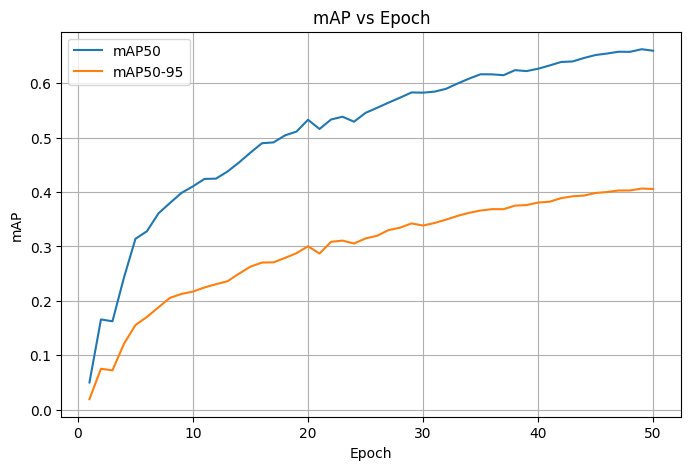

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(results['epoch'],results['metrics/mAP50(B)'],label="mAP50")
plt.plot(results['epoch'],results['metrics/mAP50-95(B)'],label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP vs Epoch")
plt.legend()
plt.grid()

plt.savefig("map_curve.png", dpi=300)
plt.show()

precision recall graph

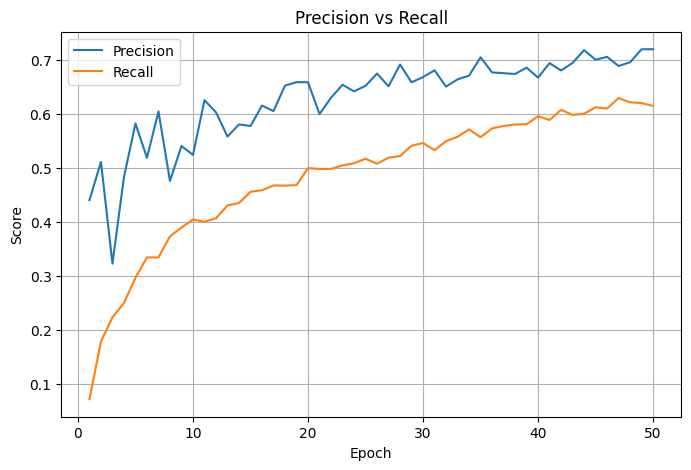

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(results['epoch'],results['metrics/precision(B)'],label="Precision")
plt.plot(results['epoch'],results['metrics/recall(B)'],label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.grid()

plt.savefig("precision_recall_curve.png", dpi=300)
plt.show()

loss curve

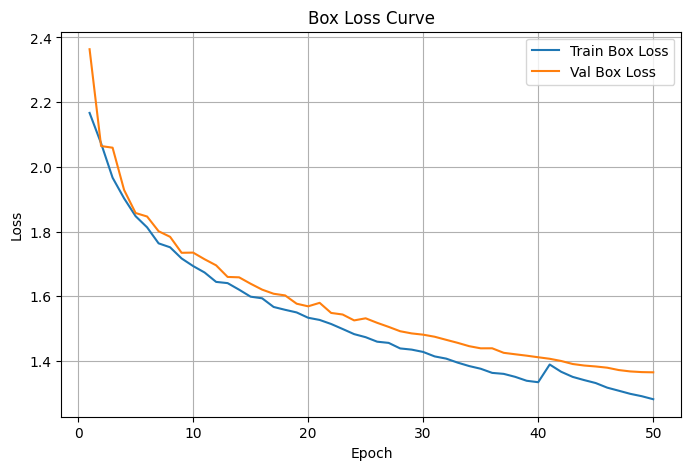

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(results['epoch'],results['train/box_loss'],label="Train Box Loss")
plt.plot(results['epoch'],results['val/box_loss'],label="Val Box Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Box Loss Curve")
plt.legend()
plt.grid()

plt.savefig("loss_curve.png", dpi=300)
plt.show()

confusion metrix

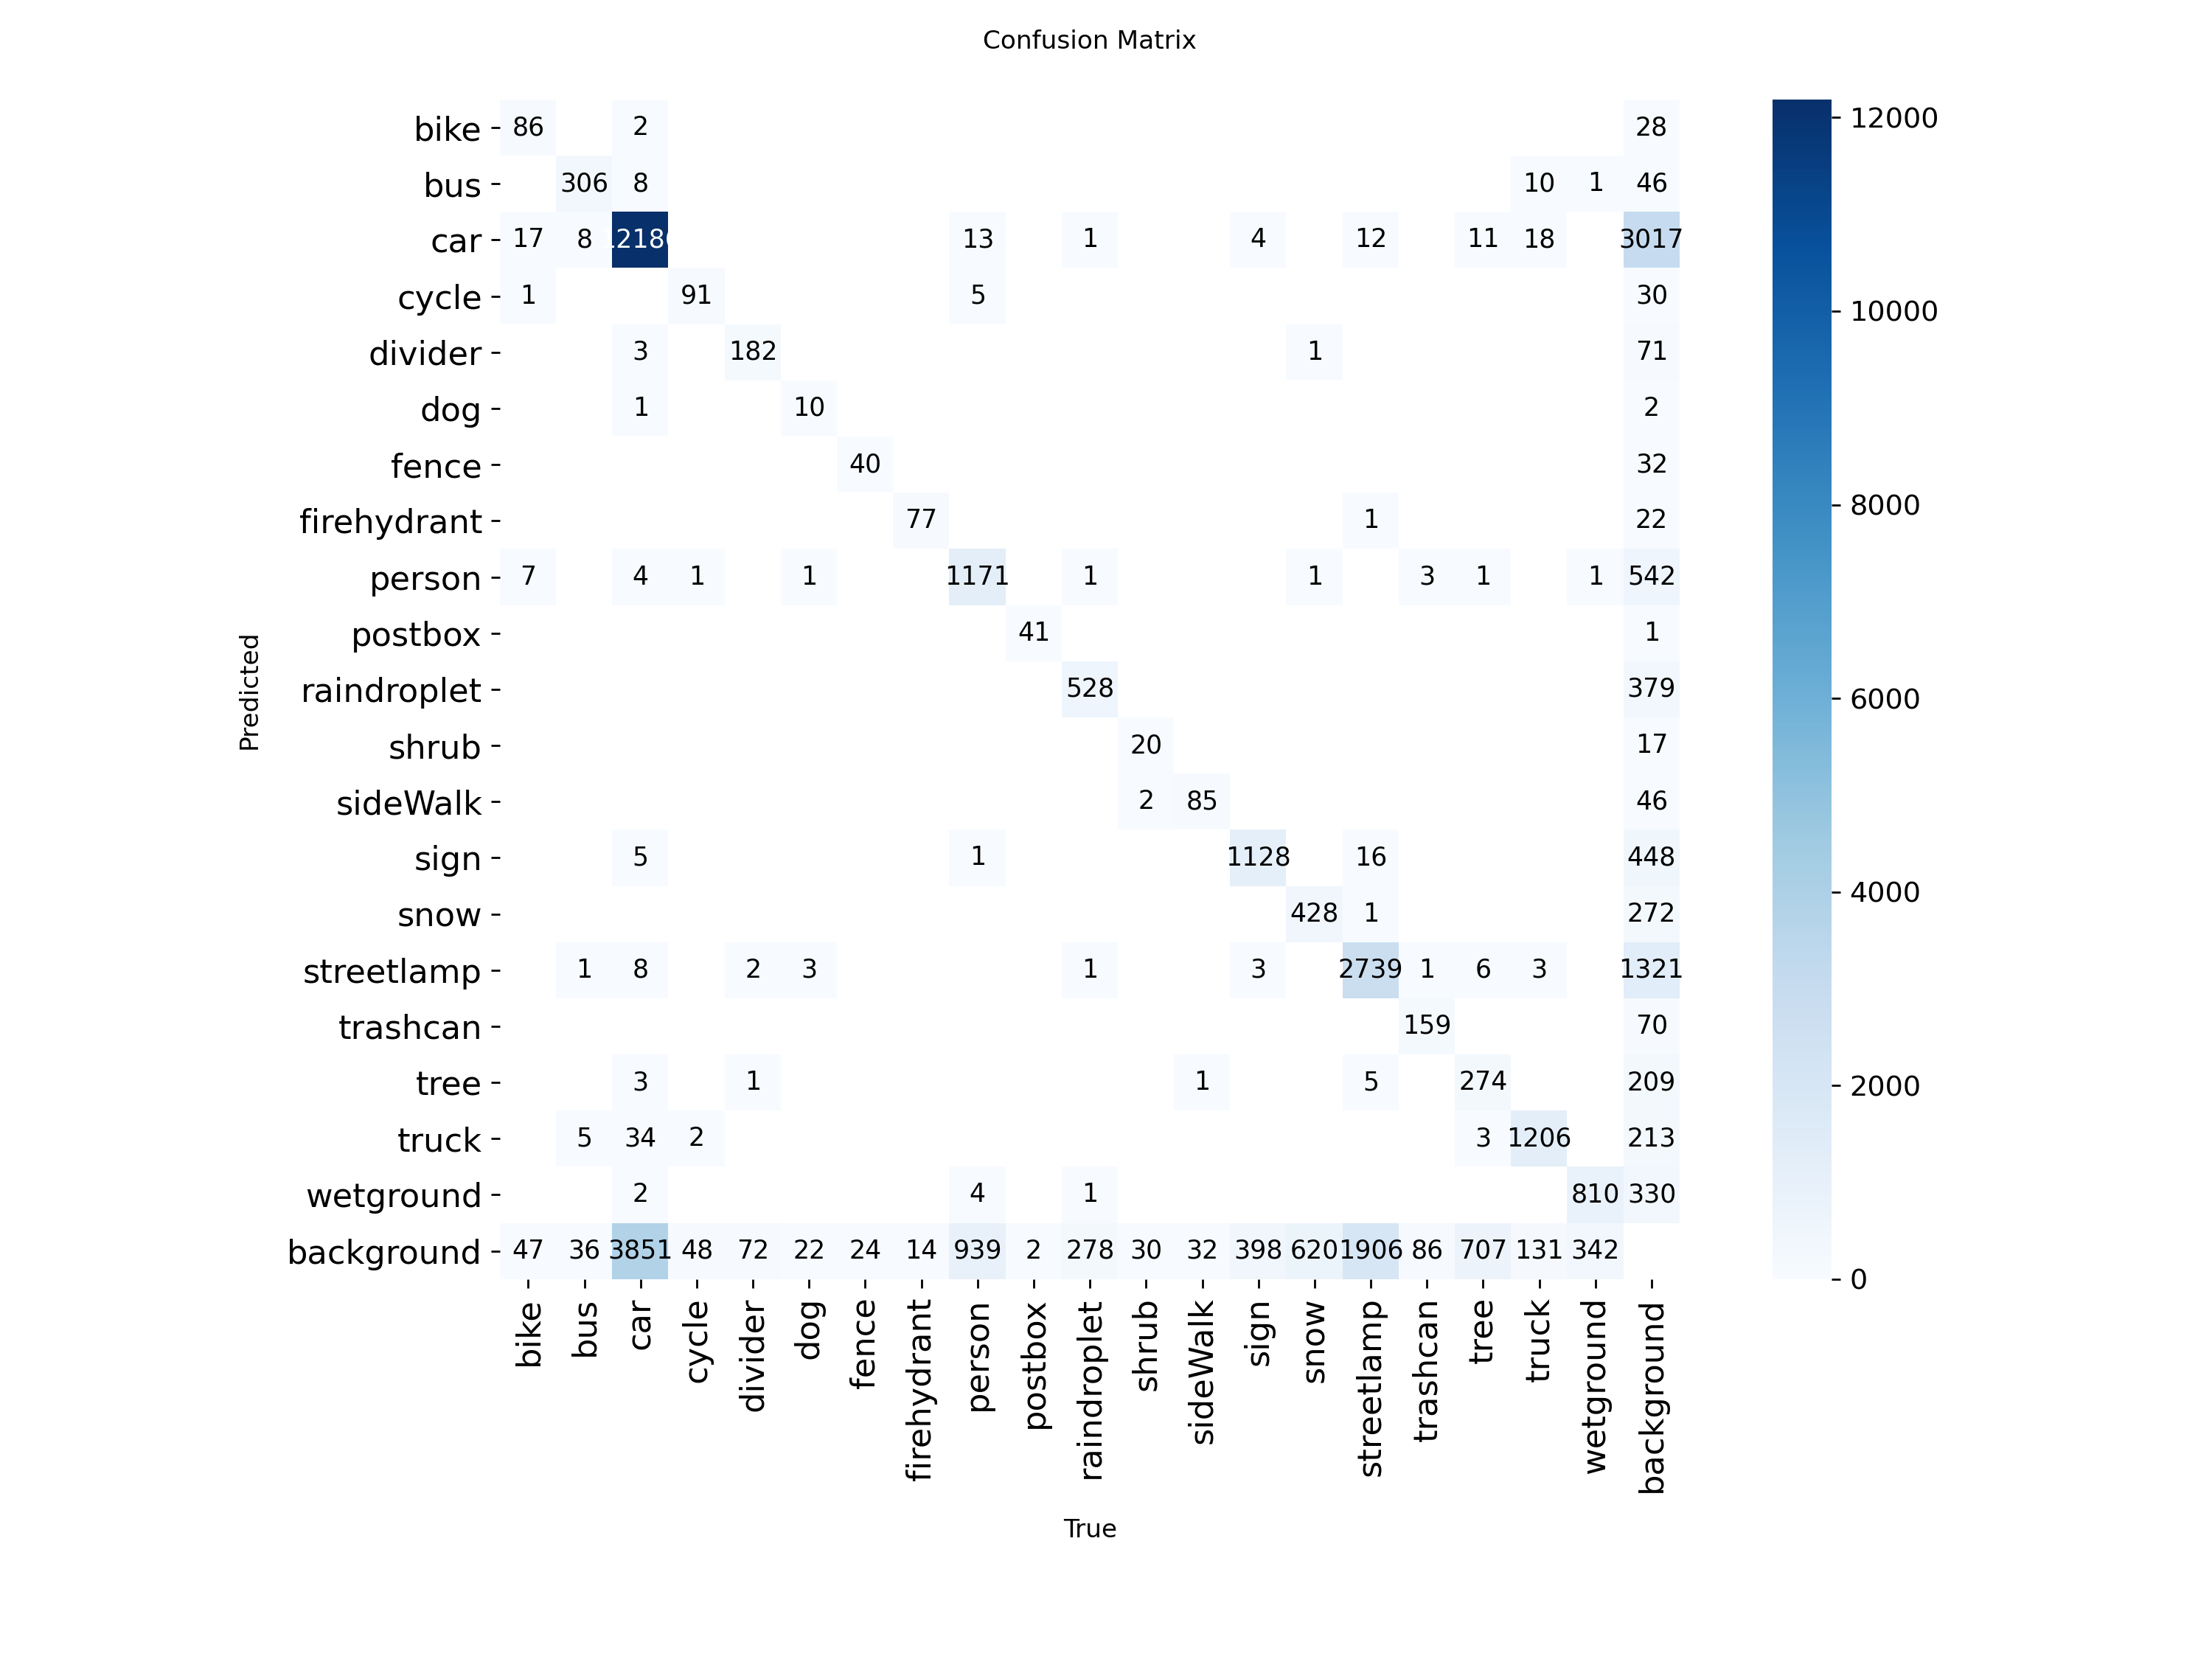

'confusion_matrix.png'

In [ ]:
from PIL import Image
from IPython.display import display

best = YOLO(f"{WORK_DIR}/weather_detection/weights/best.pt")
#best = YOLO("/content/drive/MyDrive/Thesis_Z/best_model.pt")
cm_path = f"{WORK_DIR}/weather_detection/confusion_matrix.png"

display(Image.open(cm_path))

import shutil
shutil.copy(cm_path,"confusion_matrix.png")

precision recall curve

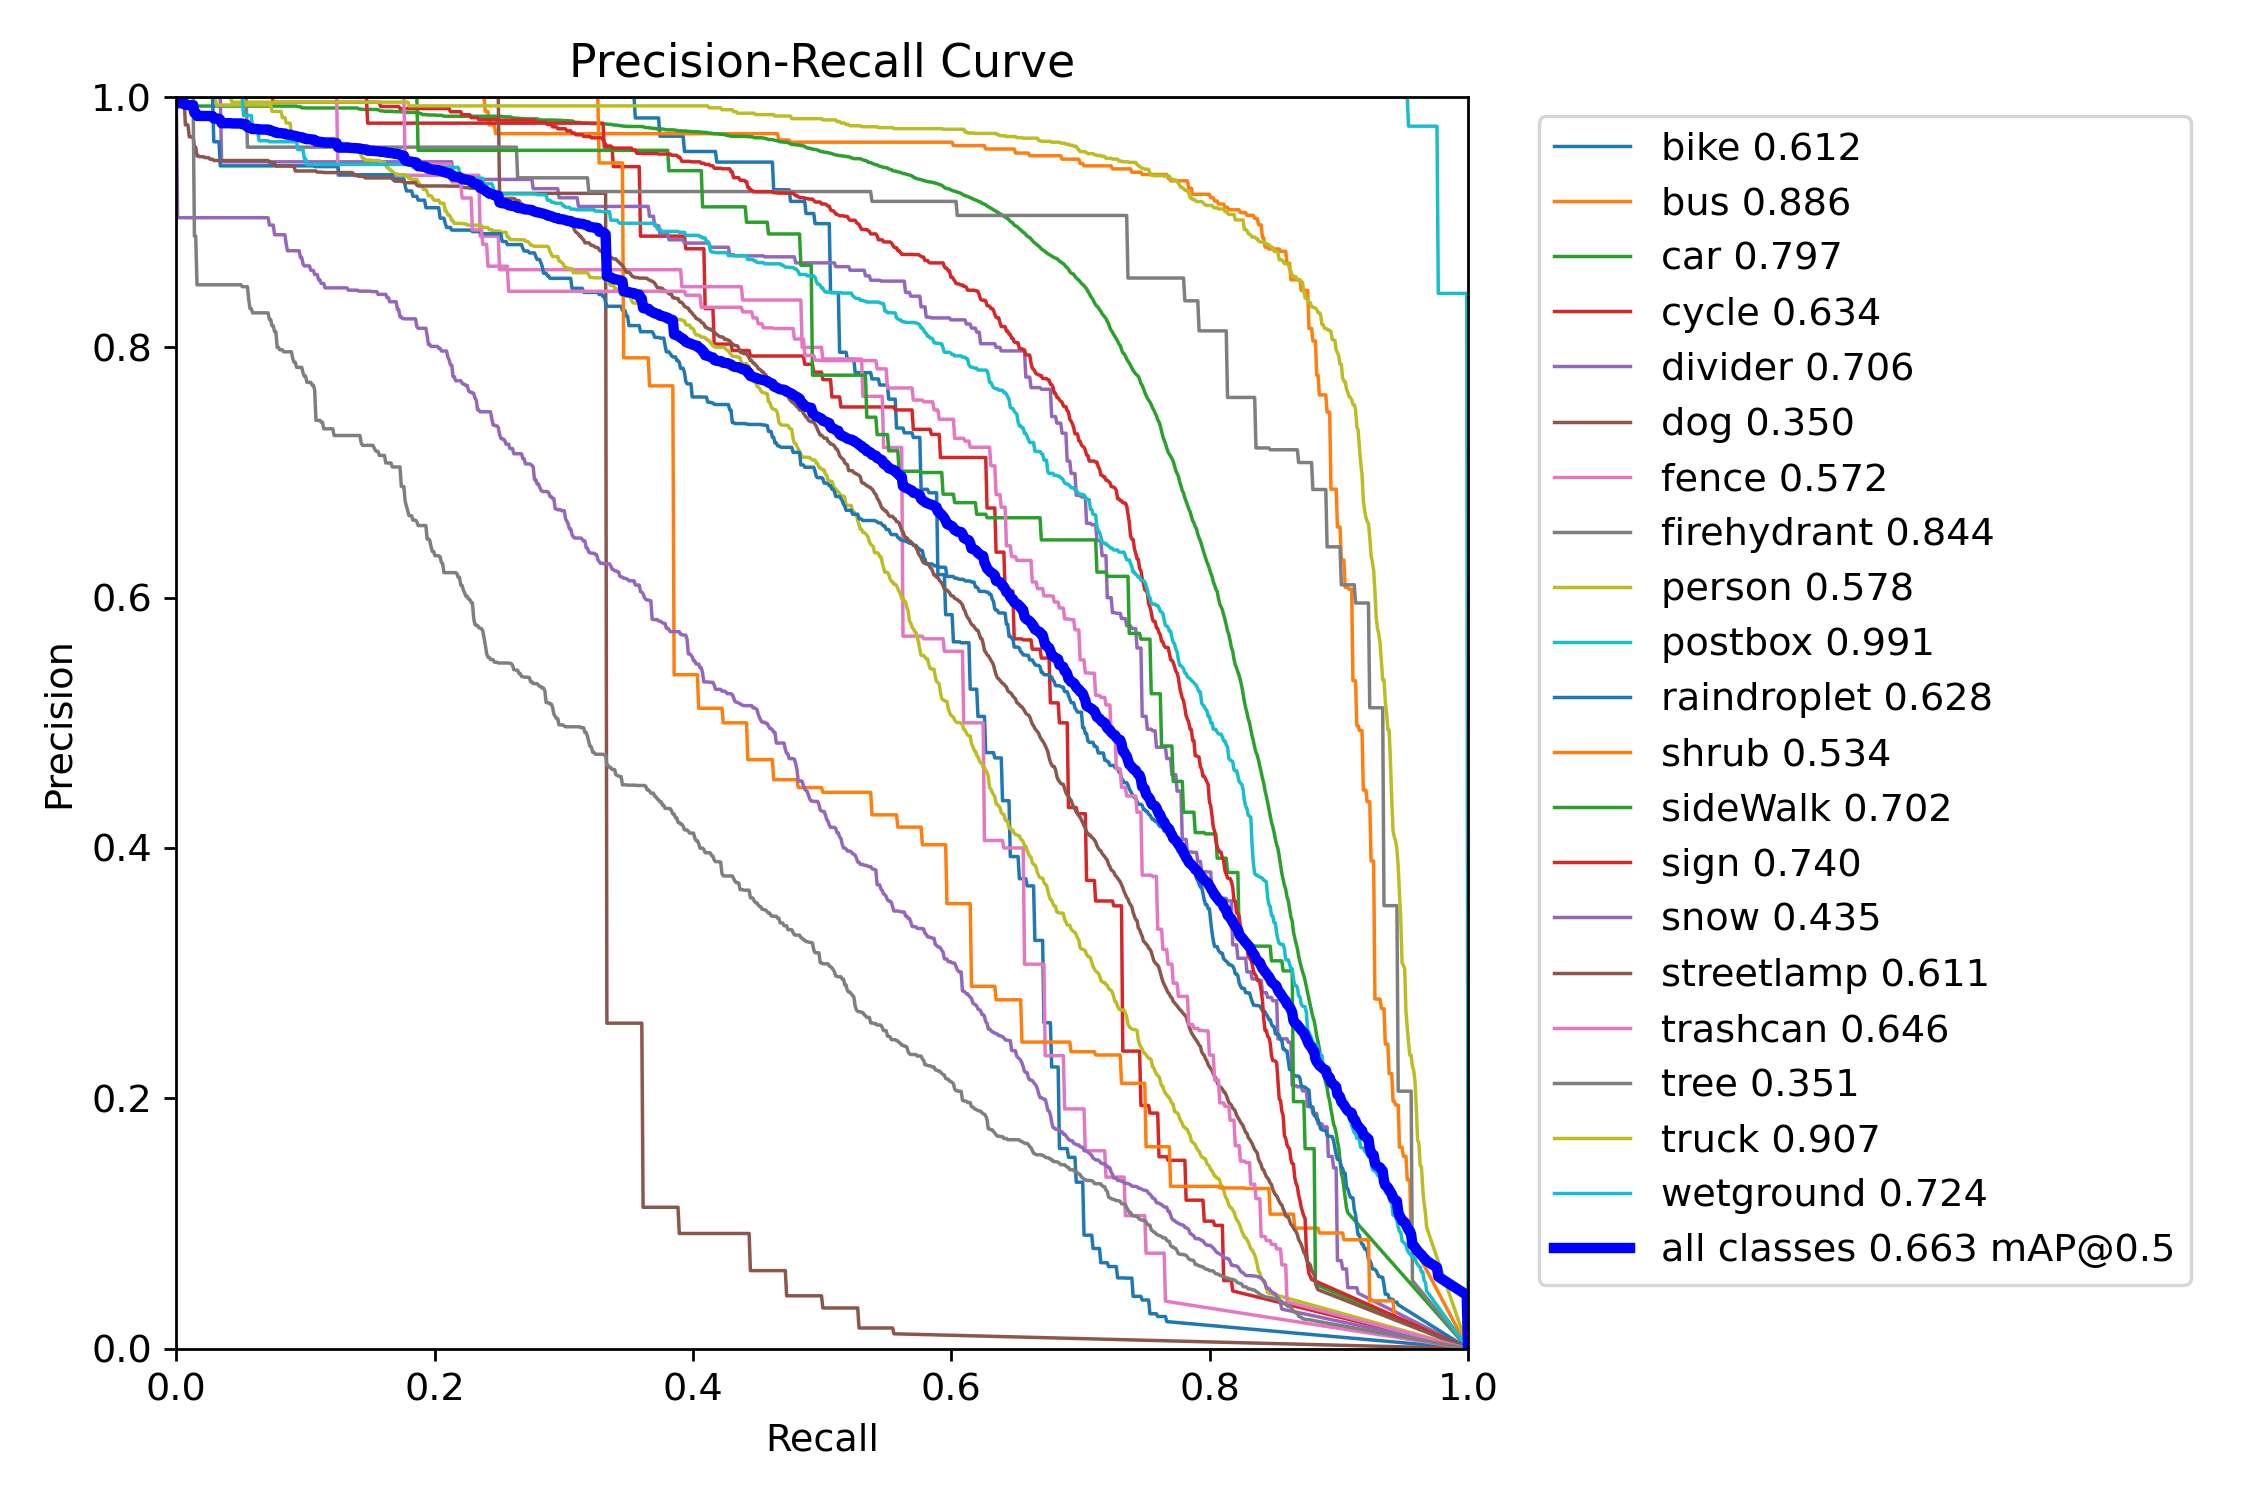

In [ ]:
from PIL import Image
from IPython.display import display

pr_path = f"{WORK_DIR}/weather_detection/BoxPR_curve.png"
display(Image.open(pr_path))

save detection result

In [ ]:
import os

PREDICT_DIR = WORK_DIR + "/test_predictions"

best.predict(
    source = FINAL_DATASET + "/test/images",
    conf = 0.25,
    save = True,
    project = WORK_DIR,
    name = "test_predictions"
)

print("All detection images saved to:", PREDICT_DIR)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1327 /content/drive/MyDrive/Thesis_Z/final_dataset/test/images/10002.jpg: 512x512 6 cars, 1 person, 2 snows, 1 tree, 25.2ms
image 2/1327 /content/drive/MyDrive/Thesis_Z/final_dataset/test/images/10012.jpg: 512x512 5 cars, 2 snows, 1 tree, 25.2ms
image 3/1327 /content/drive/MyDrive/Thesis_Z/final_dataset/test/images/10028.jpg: 512x512 4 cars, 1 person, 1 snow, 1 tree, 25.2ms
image 4/1327 /content/drive/MyDrive/Thesis_Z/final_dataset/test/images/10

In [ ]:
import shutil

DRIVE_PRED = "/content/drive/MyDrive/Thesis_Z/test_predictions"

shutil.copytree(
    WORK_DIR + "/test_predictions",
    DRIVE_PRED,
    dirs_exist_ok=True
)

print("Predictions copied to Drive.")

Predictions copied to Drive.


sample prediction

In [ ]:
import random
from IPython.display import display

sample_imgs = random.sample(os.listdir(FINAL_DATASET+"/test/images"), 15)

for img in sample_imgs:

    path = FINAL_DATASET + "/test/images/" + img

    results = best.predict(path, conf=0.25)

    display(results[0].plot())

Output hidden; open in https://colab.research.google.com to view.